# Klasifikasi Diagnosis Suara Jantung

Notebook ini berisi kode untuk training model diagnosis suara jantung dengan pendekatan Deep Learning, menggunakan Mel-Spectrogram + ResNet18.

## Pipeline

1. Download dataset dari Kaggle
2. Analisis struktur dataset
3. Load & deteksi struktur file anotasi dataset 1
4. Membangun dataframe untuk dataset 2
5. Menggabungkan kedua dataset, dan menggabungkan beberapa kelas yang dapat digabung.
6. Split train/test **per audio**, stratified terhadap kelas diagnosis
7. Segmentasi 5 detik/segmen (overlap otomatis bila durasi bukan kelipatan 5)
8. Konversi ke mel-spectrogram
9. ResNet18 dengan output **multi-kelas** sejumlah kategori diagnosis
10. Training dengan mixed precision, class-weighted loss (mengatasi imbalance), progress bar,
   evaluasi test tiap epoch
11. Checkpoint `last.pth` & `best.pth` (berbasis macro-F1 test)
12. Visualisasi loss & metrik per epoch
13. Evaluasi akhir: Accuracy, Precision, Recall, F1 (macro & weighted), Confusion Matrix multi-kelas


## 1. Setup Environment & Instalasi Dependensi

In [3]:
%pip install -q kagglehub librosa soundfile torch torchvision scikit-learn matplotlib seaborn tqdm pandas numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import math
import random
import warnings
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import soundfile as sf
import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Mount Google Drive/ Lokal Storage (untuk menyimpan & memuat checkpoint)

Checkpoint (`last.pth` & `best.pth`) akan
disimpan langsung ke **Google Drive**. 
Jika ingin menyimpan ke lokal, uncomment kode.

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

DRIVE_CHECKPOINT_DIR = "./checkpoints_combine_dataset_artifact"

## 3. Download Dataset Langsung dari Kaggle

In [6]:
import kagglehub

DATASET_ROOT = kagglehub.dataset_download("bjoernjostein/physionet-challenge-2016")
DATASET_ROOT_2 = kagglehub.dataset_download("asirisirithunga/yaseen21khan-public-heart-sounds")
print("Dataset berhasil di-download ke:", DATASET_ROOT)
print("Dataset 2 berhasil di-download ke:", DATASET_ROOT_2)

# Dataset Artifact
DATASET_ROOT_3 = kagglehub.dataset_download("zkyfauzi/heartbeat-sound")
print("Dataset 3 berhasil di-download ke:", DATASET_ROOT_2)

Dataset berhasil di-download ke: C:\Users\HP\.cache\kagglehub\datasets\bjoernjostein\physionet-challenge-2016\versions\1
Dataset 2 berhasil di-download ke: C:\Users\HP\.cache\kagglehub\datasets\asirisirithunga\yaseen21khan-public-heart-sounds\versions\1
Dataset 3 berhasil di-download ke: C:\Users\HP\.cache\kagglehub\datasets\asirisirithunga\yaseen21khan-public-heart-sounds\versions\1


## 4. Analisis Struktur Dataset

In [7]:
def print_tree(root, max_depth=3):
    root = Path(root)
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        prefix = "    " * (depth - 1) + "|-- "
        print(prefix + path.name + ("/" if path.is_dir() else ""))

print("=== Struktur folder dataset ===")
print_tree(DATASET_ROOT, max_depth=3)
print("=== Struktur folder dataset 2 ===")
print_tree(DATASET_ROOT_2, max_depth=3)


=== Struktur folder dataset ===
|-- annotations/
    |-- hand_corrected/
        |-- index.html
        |-- readme.txt
        |-- training-a_StateAns/
        |-- training-b_StateAns/
        |-- training-c_StateAns/
        |-- training-d_StateAns/
        |-- training-e_StateAns/
        |-- training-f_StateAns/
    |-- index.html
    |-- Online_Appendix_Diagnosis_meanings.csv
    |-- Online_Appendix_training_set.csv
    |-- springer_alg/
        |-- index.html
        |-- readme.txt
        |-- training-a-Aut/
        |-- training-b-Aut/
        |-- training-c-Aut/
        |-- training-d-Aut/
        |-- training-e-Aut/
        |-- training-f-Aut/
    |-- updated/
        |-- index.html
        |-- readme.txt
        |-- training-a/
        |-- training-b/
        |-- training-c/
        |-- training-d/
        |-- training-e/
        |-- training-f/
|-- training-a/
    |-- a0001.dat
    |-- a0001.hea
    |-- a0001.wav
    |-- a0002.dat
    |-- a0002.hea
    |-- a0002.wav
    |-- a

In [8]:
root_path = Path(DATASET_ROOT)
all_files = list(root_path.rglob("*.*"))
ext_counts = pd.Series([f.suffix.lower() for f in all_files]).value_counts()
print("Jumlah file berdasarkan ekstensi:")
print(ext_counts)

wav_files = [f for f in all_files if f.suffix.lower() == ".wav"]
print(f"\nTotal file .wav        : {len(wav_files)}")

Jumlah file berdasarkan ekstensi:
.mat     6306
.wav     3541
.hea     3240
.dat      405
.html      29
.csv       21
.txt        3
Name: count, dtype: int64

Total file .wav        : 3541


In [9]:
root_path_2 = Path(DATASET_ROOT_2)
all_files = list(root_path_2.rglob("*.*"))
ext_counts = pd.Series([f.suffix.lower() for f in all_files]).value_counts()
print("Jumlah file berdasarkan ekstensi:")
print(ext_counts)

wav_files = [f for f in all_files if f.suffix.lower() == ".wav"]
print(f"\nTotal file .wav        : {len(wav_files)}")

Jumlah file berdasarkan ekstensi:
.wav    1000
Name: count, dtype: int64

Total file .wav        : 1000


# 5. Load Reference.csv Dataset 1

In [10]:
def build_base_audio_index(root):
    root = Path(root)
    ref_paths = list(root.rglob("REFERENCE.csv"))
    if not ref_paths:
        ref_paths = list(root.rglob("REFERENCE-SQI.csv"))

    records = []
    for ref_path in ref_paths:
        db_folder = ref_path.parent
        db_name = db_folder.name
        wav_index = {p.stem: p for p in db_folder.rglob("*.wav")}

        df_ref = pd.read_csv(ref_path, header=None).iloc[:, :2]
        df_ref.columns = ["filename", "label_binary_raw"]

        for _, row in df_ref.iterrows():
            fname = str(row["filename"]).strip()
            wav_path = wav_index.get(fname)
            if wav_path is None:
                continue
            records.append({
                "record_id": fname,
                "filepath": str(wav_path)
            })
    return pd.DataFrame(records).drop_duplicates(subset="record_id").reset_index(drop=True)


base_df = build_base_audio_index(DATASET_ROOT)
print(f"Total audio terindeks (punya file .wav + entri REFERENCE.csv): {len(base_df)}")
display(base_df.head())


Total audio terindeks (punya file .wav + entri REFERENCE.csv): 3240


,record_id,filepath
0,a0001,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...
1,a0002,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...
2,a0003,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...
3,a0004,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...
4,a0005,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...


## 6. Load & Deteksi Struktur File Anotasi Dataset 1


In [11]:
ANNOTATION_PATH = Path(root_path / "annotations/Online_Appendix_training_set.csv")
print("File anotasi:", ANNOTATION_PATH)

diag_df_raw = pd.read_csv(ANNOTATION_PATH)
print("Shape:", diag_df_raw.shape)
print("Kolom:", list(diag_df_raw.columns))
display(diag_df_raw.head(10))


File anotasi: C:\Users\HP\.cache\kagglehub\datasets\bjoernjostein\physionet-challenge-2016\versions\1\annotations\Online_Appendix_training_set.csv
Shape: (3153, 26)
Kolom: ['Challenge record name', 'Database', 'Original record name', 'Diagnosis', 'Class (-1=normal 1=abnormal)', '# Beat (automated algorithm)', '# Beats requiring hand correction', 'Gender', 'Age (year)', 'Height (m)', 'Weight (kg)', 'BMI', 'Smoker', 'Degree of disease', 'Subject ID', '# Raw record', '# Recording in each subject', 'Transducer site on body', 'Recording state', 'Murmurs (2=None 3=Weak 4=Strong 6=Unclear)', 'Murmur Location (2=Sys,3=Dia,4=Both)', 'Arrhythmia (2=None 3=One arrhythmic beat 4=Medium Arrhytmia 5=Severe Arrhytmia 6=Unclear 7=Two arrhythmic beats)', 'Respiration noise (2=None 3=Insignificant 4=Weak Resp. Noise<2 s 5=Weak Resp. Noise<3 s 6=Weak Resp. Noise <4 s 7=Weak Resp. Noise >4 s 8=Powerfull Resp. Noise<2 s 9=Powerfull Resp. Noise<3 s 10=Powerfull Resp. noise <4 s  11=Powerfull Resp. Noise >4 

,Challenge record name,Database,Original record name,Diagnosis,Class (-1=normal 1=abnormal),# Beat (automated algorithm),# Beats requiring hand correction,Gender,Age (year),Height (m),...,# Recording in each subject,Transducer site on body,Recording state,Murmurs (2=None 3=Weak 4=Strong 6=Unclear),"Murmur Location (2=Sys,3=Dia,4=Both)",Arrhythmia (2=None 3=One arrhythmic beat 4=Medium Arrhytmia 5=Severe Arrhytmia 6=Unclear 7=Two arrhythmic beats),Respiration noise (2=None 3=Insignificant 4=Weak Resp. Noise<2 s 5=Weak Resp. Noise<3 s 6=Weak Resp. Noise <4 s 7=Weak Resp. Noise >4 s 8=Powerfull Resp. Noise<2 s 9=Powerfull Resp. Noise<3 s 10=Powerfull Resp. noise <4 s 11=Powerfull Resp. Noise >4 s 12=Dont know 13=Weak Resp. Noise<1 s 14=Resp. Noise<1 s 15=Powerfull Resp. noise <1 s 16=Weak Rec. Noise<1 s 17=Powerfull Rec. Noise<1 s),Ambient noise (2=None 3=Insignificant 4=Weak Rec. BG<2 s 5=Weak Rec. BG<3 s 6=Weak Rec. BG <4 s 7=Weak Rec. BG >4 s 8=BG. Noise<2 s 9=BG. Noise<3 s 10= BG. noise <4 s 11=BG. Noise >4 s 12=Powerfull BG. Noise<2 s 13=Powerfull BG. Noise<3 s 14=Powerfull BG. noise <4 s 15=Powerfull BG. Noise >4 s 16=Dont know 17=Weak BG. Noise<1 s 18=BG.Noise<1 s 19=Powerfull BG. Noise<1 s),Recording noise (2=None 3=Insignificant 4=Beg. Rec. Noise 5=End Rec. Noise 6=Beg-End Reco Noise 7=Weak Rec. Noise<2 s 8=Weak Rec. Noise<3 s 9=Weak Rec. Noise <4 s 10=Weak Rec. Noise >4 s 11=Powerfull Rec. Noise<2 s 12=Powerfull Rec. Noise<3 s 13=Powerfull Rec. noise <4 s 14=Powerfull Rec. Noise >4 s 15=Spikes 16=Dont know 17=Weak Rec. Noise<1 s 18=Powerfull Rec. Noise<1 s),Abdominal sounds (2=None 3=Insignificant 4=Sto. Noise<2 s 5=Sto. Noise<3 s 6=Sto. Noise <4 s 7=Sto. Noise >4 s 8=Dont know 9=Sto. Noise<1 s)
0,a0001,training-a,C45S1,MVP,1,36,0,NaN,NaN,NaN,...,NaN,Left of parasternum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a0002,training-a,C19S3,MVP,1,27,7,NaN,NaN,NaN,...,NaN,Parasternum when sit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a0003,training-a,C23S0,MVP,1,25,0,NaN,NaN,NaN,...,NaN,Left of parasternum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,a0004,training-a,C35S18,Benign,1,35,0,NaN,NaN,NaN,...,NaN,Left of parasternum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,a0005,training-a,C63S20,Benign,1,52,0,NaN,NaN,NaN,...,NaN,Parasternum when squat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,a0006,training-a,C12S4,AD,1,27,27,NaN,NaN,NaN,...,NaN,2nd right intercostal space,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,a0007,training-a,C37S2,Normal,-1,52,27,NaN,NaN,NaN,...,NaN,Parasternum when sit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,a0008,training-a,C73S1,MVP,1,51,51,NaN,NaN,NaN,...,NaN,Left of apex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,a0009,training-a,C63S12,Normal,-1,46,0,NaN,NaN,NaN,...,NaN,Parasternum when squat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,a0010,training-a,C31S4,Benign,1,44,0,NaN,NaN,NaN,...,NaN,Parasternum when squat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
id_col = "Challenge record name"
diag_col = "Diagnosis"

diag_df = diag_df_raw[[id_col, diag_col]].copy()
diag_df.columns = ["record_id", "diagnosis"]
diag_df["record_id"] = diag_df["record_id"].astype(str).str.strip()
diag_df["diagnosis"] = diag_df["diagnosis"].astype(str).str.strip()
diag_df = diag_df.dropna(subset=["diagnosis"])
diag_df = diag_df[diag_df["diagnosis"].str.lower() != "nan"]

metadata_df = base_df.merge(diag_df, on="record_id", how="inner")
print(f"Jumlah audio dengan label diagnosis valid: {len(metadata_df)} (dari {len(base_df)} audio terindeks)")

print("\nDistribusi kelas diagnosis (sebelum penggabungan kelas langka):")
print(metadata_df["diagnosis"].value_counts())
display(metadata_df.head())


Jumlah audio dengan label diagnosis valid: 3153 (dari 3240 audio terindeks)

Distribusi kelas diagnosis (sebelum penggabungan kelas langka):
diagnosis
Normal             2454
CAD                 287
MVP                 134
Benign              118
Pathologic           62
MPC                  23
AD                   17
Normal: MARS500      14
Normal: NHC          13
MR                   12
AS                   12
Controls              7
Name: count, dtype: int64


,record_id,filepath,diagnosis
0,a0001,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP
1,a0002,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP
2,a0003,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP
3,a0004,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,Benign
4,a0005,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,Benign


## 7. Merge Load Dataset 2 & 3

In [13]:
def build_dataset_2_index(root):
    root = Path(root)
    records = []
    label_map = {
        'AS': 'AS',
        'MR': 'MR',
        'MS': 'MS',
        'MVP': 'MVP',
        'N': 'Normal'
    }

    for folder in root.iterdir():
        if folder.is_dir():
            raw_label = folder.name.replace('_New', '').strip()
            diagnosis = label_map.get(raw_label)

            if diagnosis:
                for wav_path in folder.rglob("*.wav"):
                    records.append({
                        "record_id": wav_path.stem,
                        "filepath": str(wav_path),
                        "diagnosis": diagnosis
                    })
    return pd.DataFrame(records)

df2 = build_dataset_2_index(DATASET_ROOT_2)
print(f"Total audio from Dataset 2: {len(df2)}")
print("Distribusi Dataset 2:\n", df2['diagnosis'].value_counts())


Total audio from Dataset 2: 1000
Distribusi Dataset 2:
 diagnosis
AS        200
MR        200
MS        200
MVP       200
Normal    200
Name: count, dtype: int64


In [14]:
def build_dataset_3_index(root):
    root = Path(root)
    records = []
    for folder in root.iterdir():
        if folder.is_dir() and folder.name == "Artifact":
            diagnosis = "Artifact"
            for wav_path in folder.rglob("*.wav"):
                records.append({
                    "record_id": wav_path.stem,
                    "filepath": str(wav_path),
                    "diagnosis": diagnosis
                })
    return pd.DataFrame(records)

df3 = build_dataset_3_index(DATASET_ROOT_3)
print(f"Total audio from Dataset 3: {len(df3)}")
print("Distribusi Dataset 3:\n", df3['diagnosis'].value_counts())

Total audio from Dataset 3: 80


Distribusi Dataset 3:
 diagnosis
Artifact    80
Name: count, dtype: int64


## 8. Merge Dataset

In [15]:
df1 = base_df.merge(diag_df, on="record_id", how="inner")

# Combine both dataframes
metadata_df = pd.concat([df1, df2, df3], ignore_index=True)
print(f"\nTotal combined metadata: {len(metadata_df)}")

print(metadata_df['diagnosis'].value_counts())

display(df2.head(10))


Total combined metadata: 4233
diagnosis
Normal             2654
MVP                 334
CAD                 287
MR                  212
AS                  212
MS                  200
Benign              118
Artifact             80
Pathologic           62
MPC                  23
AD                   17
Normal: MARS500      14
Normal: NHC          13
Controls              7
Name: count, dtype: int64


,record_id,filepath,diagnosis
0,New_AS_001,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
1,New_AS_002,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
2,New_AS_003,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
3,New_AS_004,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
4,New_AS_005,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
5,New_AS_006,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
6,New_AS_007,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
7,New_AS_008,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
8,New_AS_009,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS
9,New_AS_010,C:\Users\HP\.cache\kagglehub\datasets\asirisir...,AS


## 9. Combine Class

Menggabungkan kelas Normal, Mitral Valve Problem, dan Aortic Problem
['Normal: MARS500', 'Normal: NHC', 'Controls']
['AS', 'AD']
['Pathologic', 'MPC']

Distribusi kelas diagnosis (final):
diagnosis
Normal      2688
MVP          334
CAD          287
AP           229
MR           212
MS           200
Benign       118
PC            85
Artifact      80
Name: count, dtype: int64


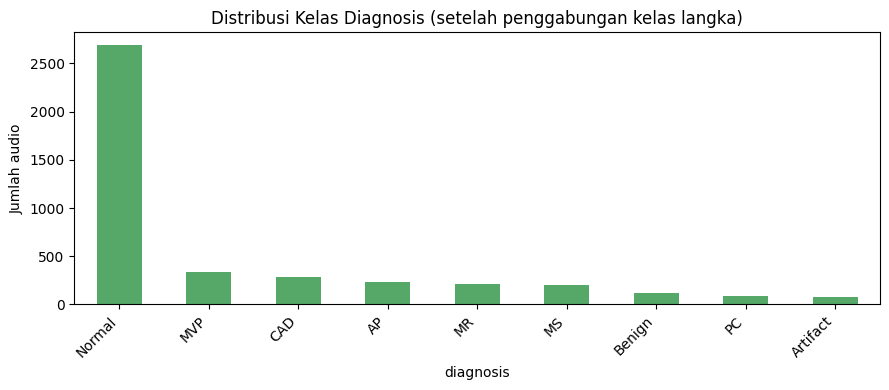

In [16]:
class_counts = metadata_df["diagnosis"].value_counts()
normal_classes = ["Normal: MARS500", "Normal: NHC", "Controls"]
# mitral_valve_problem_classes = ["MVP", "MR", "MS"]
aortic_problem_classes = ["AS", "AD"]
pathological_condition_classes = ["Pathologic", "MPC"]

print(f"Menggabungkan kelas Normal, Mitral Valve Problem, dan Aortic Problem")
print(normal_classes)
print(aortic_problem_classes)
print(pathological_condition_classes)
metadata_df["diagnosis"] = metadata_df["diagnosis"].apply(
  lambda d: "Normal" if d in normal_classes else d
).apply(
  lambda d: "AP" if d in aortic_problem_classes else d
).apply(
  lambda d: "PC" if d in pathological_condition_classes else d
)


print("\nDistribusi kelas diagnosis (final):")
final_counts = metadata_df["diagnosis"].value_counts()
print(final_counts)

plt.figure(figsize=(9, 4))
final_counts.plot(kind="bar", color="#55A868")
plt.ylabel("Jumlah audio")
plt.title("Distribusi Kelas Diagnosis (setelah penggabungan kelas langka)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
label_encoder = LabelEncoder()
metadata_df["label"] = label_encoder.fit_transform(metadata_df["diagnosis"])
CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Jumlah kelas diagnosis final: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

display(metadata_df.head())


Jumlah kelas diagnosis final: 9
  0: AP
  1: Artifact
  2: Benign
  3: CAD
  4: MR
  5: MS
  6: MVP
  7: Normal
  8: PC


,record_id,filepath,diagnosis,label
0,a0001,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP,6
1,a0002,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP,6
2,a0003,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,MVP,6
3,a0004,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,Benign,2
4,a0005,C:\Users\HP\.cache\kagglehub\datasets\bjoernjo...,Benign,2


## 10. Split Dataset (Train / Test) - Level Audio

In [18]:
TEST_SIZE = 0.2

try:
    train_df, test_df = train_test_split(
        metadata_df, test_size=TEST_SIZE, stratify=metadata_df["label"], random_state=SEED,
    )
except ValueError as e:
    print(f"Stratified split gagal ({e}); fallback ke split non-stratified.")
    train_df, test_df = train_test_split(
        metadata_df, test_size=TEST_SIZE, random_state=SEED,
    )

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Jumlah audio train : {len(train_df)}")
print(f"Jumlah audio test  : {len(test_df)}")

print("\nDistribusi kelas - train:")
print(train_df["diagnosis"].value_counts())
print("\nDistribusi kelas - test:")
print(test_df["diagnosis"].value_counts())

overlap = set(train_df["record_id"]) & set(test_df["record_id"])
assert len(overlap) == 0, f"Data leakage terdeteksi! {overlap}"
print("\nOK: tidak ada overlap record antara train dan test.")


Jumlah audio train : 3386
Jumlah audio test  : 847

Distribusi kelas - train:
diagnosis
Normal      2150
MVP          267
CAD          230
AP           183
MR           170
MS           160
Benign        94
PC            68
Artifact      64
Name: count, dtype: int64

Distribusi kelas - test:
diagnosis
Normal      538
MVP          67
CAD          57
AP           46
MR           42
MS           40
Benign       24
PC           17
Artifact     16
Name: count, dtype: int64

OK: tidak ada overlap record antara train dan test.


## 11. Segmentasi Audio (5 detik per segmen, overlap otomatis)

Segmen 5 detik, tanpa overlap jika durasi audio kelipatan 5
detik, dan overlap terdistribusi merata jika bukan kelipatan. Label diagnosis ikut dibawa ke tiap segmen.

In [19]:
TARGET_SR = 4000
SEGMENT_SEC = 5.0
SEGMENT_SAMPLES = int(SEGMENT_SEC * TARGET_SR)


def get_segment_starts(total_samples, seg_samples):
    if total_samples <= seg_samples:
        return [0]
    n_segments = math.ceil(total_samples / seg_samples)
    if n_segments <= 1:
        return [0]
    if total_samples % seg_samples == 0:
        starts = [i * seg_samples for i in range(n_segments)]
    else:
        step = (total_samples - seg_samples) / (n_segments - 1)
        starts = [int(round(i * step)) for i in range(n_segments)]
        starts[-1] = total_samples - seg_samples
    return starts


def build_segment_index(df, target_sr=TARGET_SR, seg_samples=SEGMENT_SAMPLES):
    segments = []
    for _, row in df.iterrows():
        info = sf.info(row["filepath"])
        native_duration = info.frames / info.samplerate
        total_samples_target = int(round(native_duration * target_sr))
        starts = get_segment_starts(total_samples_target, seg_samples)
        for s in starts:
            segments.append({
                "filepath": row["filepath"],
                "start_sample": s,
                "label": row["label"],
                "diagnosis": row["diagnosis"],
                "record_id": row["record_id"],
            })
    return pd.DataFrame(segments)


train_segments_df = build_segment_index(train_df)
test_segments_df = build_segment_index(test_df)

print(f"Jumlah segmen train : {len(train_segments_df)}  (dari {len(train_df)} audio)")
print(f"Jumlah segmen test  : {len(test_segments_df)}  (dari {len(test_df)} audio)")
print("\nDistribusi kelas segmen - train:")
print(train_segments_df["diagnosis"].value_counts())


Jumlah segmen train : 13611  (dari 3386 audio)
Jumlah segmen test  : 3404  (dari 847 audio)

Distribusi kelas segmen - train:
diagnosis
Normal      9760
MVP         1010
CAD          851
Benign       683
PC           426
AP           341
MR           252
MS           160
Artifact     128
Name: count, dtype: int64


## 12. Oversampling Audio

In [20]:
# def balance_dataset_by_oversampling(df, target_class='Normal'):
#     """
#     Melakukan oversampling pada setiap kelas agar jumlahnya menyamai target_class.
#     """
#     target_count = len(df[df['diagnosis'] == target_class])
#     df_balanced = df[df['diagnosis'] == target_class]

#     other_classes = [c for c in df['diagnosis'].unique() if c != target_class]

#     for cls in other_classes:
#         df_cls = df[df['diagnosis'] == cls]
#         current_count = len(df_cls)

#         if current_count < target_count:
#             # Hitung berapa kali perlu replikasi
#             resample_ratio = math.ceil(target_count / current_count)
#             df_resampled = pd.concat([df_cls] * resample_ratio).iloc[:target_count]
#             df_balanced = pd.concat([df_balanced, df_resampled], ignore_index=True)
#         else:
#             df_balanced = pd.concat([df_balanced, df_cls], ignore_index=True)

#     return df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

# # Melakukan oversampling pada data training
# print(f"Jumlah segmen train sebelum oversampling: {len(train_segments_df)}")
# train_segments_balanced_df = balance_dataset_by_oversampling(train_segments_df, target_class='Normal')

# print(f"Jumlah segmen train setelah oversampling: {len(train_segments_balanced_df)}")
# print("\nDistribusi kelas setelah oversampling:")
# print(train_segments_balanced_df['diagnosis'].value_counts())

# # Update train_loader dengan dataset yang sudah seimbang
# # Pastikan transform=True tetap aktif agar sampel yang direplikasi mendapatkan augmentasi berbeda
# train_dataset_balanced = HeartSoundSegmentDataset(train_segments_balanced_df, transform=True)
# train_loader = DataLoader(
#     train_dataset_balanced, batch_size=BATCH_SIZE, shuffle=True,
#     num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
# )

## 13. Mel-Spectrogram & Dataset PyTorch

In [21]:
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256


@lru_cache(maxsize=64)
def load_audio_cached(filepath):
    y, _ = librosa.load(filepath, sr=TARGET_SR, mono=True)
    return y


def extract_segment_waveform(filepath, start_sample, seg_samples=SEGMENT_SAMPLES):
    y = load_audio_cached(filepath)
    end_sample = start_sample + seg_samples
    if end_sample <= len(y):
        segment = y[start_sample:end_sample]
    else:
        segment = y[start_sample:]
        pad_len = seg_samples - len(segment)
        segment = np.pad(segment, (0, pad_len), mode="constant")
    return segment.astype(np.float32)


def waveform_to_melspectrogram(y, sr=TARGET_SR):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mean, std = mel_db.mean(), mel_db.std()
    mel_norm = (mel_db - mean) / (std + 1e-6)
    return mel_norm.astype(np.float32)


class HeartSoundSegmentDataset(Dataset):
    def __init__(self, segments_df):
        self.segments_df = segments_df.reset_index(drop=True)

    def __len__(self):
        return len(self.segments_df)

    def __getitem__(self, idx):
        row = self.segments_df.iloc[idx]
        waveform = extract_segment_waveform(row["filepath"], int(row["start_sample"]))
        mel = waveform_to_melspectrogram(waveform)
        mel_tensor = torch.from_numpy(mel).unsqueeze(0)  # (1, n_mels, time)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return mel_tensor, label


In [22]:
def augment_audio(y, sr=TARGET_SR):
    """Advanced heart sound specific augmentation."""
    choice = random.random()

    # 1. Time Stretching (Simulating different heart rates)
    if choice < 0.25:
        rate = random.uniform(0.8, 1.2)
        y = librosa.effects.time_stretch(y, rate=rate)

    # 2. Pitch Shifting (Simulating physical variations in valves)
    elif choice < 0.50:
        steps = random.uniform(-1.5, 1.5)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

    # 3. Add Gaussian Noise (Simulating ambient/sensor noise)
    elif choice < 0.75:
        noise_amp = 0.005 * np.random.uniform() * np.amax(y)
        y = y + noise_amp * np.random.normal(size=y.shape[0])

    # 4. Random Gain
    else:
        y = y * random.uniform(0.7, 1.3)

    return y.astype(np.float32)

class HeartSoundSegmentDataset(Dataset):
    def __init__(self, segments_df, transform=False):
        self.segments_df = segments_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.segments_df)

    def __getitem__(self, idx):
        row = self.segments_df.iloc[idx]
        waveform = extract_segment_waveform(row["filepath"], int(row["start_sample"]))

        # Terapkan augmentasi jika mode training
        if self.transform:
            waveform = augment_audio(waveform)
            # Pastikan panjang tetap SEGMENT_SAMPLES setelah stretching
            if len(waveform) > SEGMENT_SAMPLES:
                waveform = waveform[:SEGMENT_SAMPLES]
            else:
                waveform = np.pad(waveform, (0, max(0, SEGMENT_SAMPLES - len(waveform))), mode='constant')

        mel = waveform_to_melspectrogram(waveform)
        mel_tensor = torch.from_numpy(mel).unsqueeze(0)  # (1, n_mels, time)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return mel_tensor, label

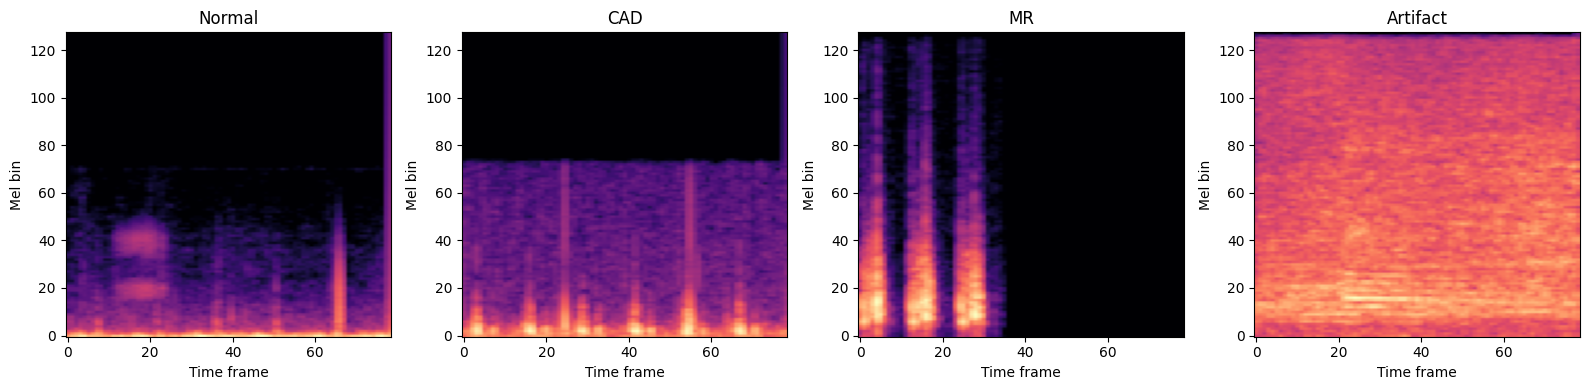

In [23]:
sample_classes = train_segments_df["diagnosis"].unique()[:4]
fig, axes = plt.subplots(1, len(sample_classes), figsize=(4 * len(sample_classes), 4))
if len(sample_classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, sample_classes):
    sample_row = train_segments_df[train_segments_df["diagnosis"] == cls].iloc[0]
    wf = extract_segment_waveform(sample_row["filepath"], int(sample_row["start_sample"]))
    mel = waveform_to_melspectrogram(wf)
    ax.imshow(mel, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(cls)
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel bin")
plt.tight_layout()
plt.show()


## 14. DataLoader

In [25]:
BATCH_SIZE = 64
NUM_WORKERS = 0

train_dataset = HeartSoundSegmentDataset(train_segments_df, transform=True)
test_dataset = HeartSoundSegmentDataset(test_segments_df, transform=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, "| Label shape:", yb.shape, "| Jumlah kelas:", NUM_CLASSES)


Batch shape: torch.Size([64, 1, 128, 79]) | Label shape: torch.Size([64]) | Jumlah kelas: 9


## 15. Model — ResNet18 Multi-Kelas

In [26]:
def build_resnet18(num_classes, in_channels=1, pretrained=True):
    weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
    model = torchvision.models.resnet18(weights=weights)

    old_conv = model.conv1
    new_conv = nn.Conv2d(
        in_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=False,
    )
    if pretrained:
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.sum(dim=1, keepdim=True))
    model.conv1 = new_conv
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


model = build_resnet18(num_classes=NUM_CLASSES, in_channels=1, pretrained=True).to(DEVICE)
print(model.conv1)
print(model.fc)

Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=9, bias=True)


## 16. Class-Weighted Loss, Checkpoint (Google Drive/ Lokal) & Mixed Precision

Karena kelas diagnosis sangat tidak seimbang (mayoritas Normal, sisanya beragam
kondisi dengan jumlah kecil), loss menggunakan **class weighting** (inverse frequency) agar
kelas minoritas tidak diabaikan model.

Checkpoint disimpan ke`DRIVE_CHECKPOINT_DIR`:
- `last.pth` — selalu ditimpa tiap akhir epoch (checkpoint paling baru)
- `best.pth` — ditimpa setiap kali **macro F1-score** test pada epoch tersebut adalah yang
  terbaik sejauh ini (macro F1 dipilih karena lebih representatif untuk multi-kelas yang
  imbalanced dibanding accuracy)

Jika `last.pth` sudah ada di Drive dari sesi sebelumnya (mis. Colab terputus di tengah
training), training akan otomatis **melanjutkan (resume)** dari epoch terakhir — atur
`RESUME_FROM_DRIVE = False` di bawah untuk selalu mulai dari awal.

In [28]:
CHECKPOINT_DIR = Path(DRIVE_CHECKPOINT_DIR)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LAST_CKPT_PATH = CHECKPOINT_DIR / "last.pth"
BEST_CKPT_PATH = CHECKPOINT_DIR / "best.pth"

RESUME_FROM_DRIVE = False

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# class weights berbasis distribusi label di TRAIN SEGMENTS
class_sample_counts = train_segments_df["label"].value_counts().sort_index()
class_sample_counts = class_sample_counts.reindex(range(NUM_CLASSES)).fillna(1)  # hindari div-by-zero
class_weights = 1.0 / class_sample_counts.values
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights per kelas:")
for name, w in zip(CLASS_NAMES, class_weights):
    print(f"  {name}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

USE_AMP = DEVICE.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def save_checkpoint(state, path):
    torch.save(state, path)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(xb)
                loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0, labels=range(NUM_CLASSES)
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0, labels=range(NUM_CLASSES)
    )
    return {
        "loss": avg_loss, "accuracy": acc,
        "precision_macro": precision_macro, "recall_macro": recall_macro, "f1_macro": f1_macro,
        "precision_weighted": precision_weighted, "recall_weighted": recall_weighted, "f1_weighted": f1_weighted,
        "y_true": all_labels, "y_pred": all_preds,
    }


Class weights per kelas:
  AP: 0.976
  Artifact: 2.600
  Benign: 0.487
  CAD: 0.391
  MR: 1.321
  MS: 2.080
  MVP: 0.330
  Normal: 0.034
  PC: 0.781


## 17. Muat Checkpoint dari Google Drive (Resume Training)

Jika `RESUME_FROM_DRIVE=True` dan file `last.pth` ditemukan di `DRIVE_CHECKPOINT_DIR`, state
model, optimizer, scaler (AMP), history, serta epoch terakhir akan dipulihkan, sehingga
training epoch berikutnya melanjutkan dari titik terakhir alih-alih mengulang dari awal.

In [29]:
history = {
    "train_loss": [], "test_loss": [], "test_accuracy": [],
    "test_f1_macro": [], "test_f1_weighted": [],
    "test_precision_macro": [], "test_recall_macro": [],
}
best_f1_macro = -1.0
start_epoch = 1

if RESUME_FROM_DRIVE:
    print(f"Ditemukan checkpoint di Drive: {LAST_CKPT_PATH} -> memuat untuk melanjutkan training...")
    resumed = torch.load(LAST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(resumed["model_state_dict"])
    optimizer.load_state_dict(resumed["optimizer_state_dict"])
    scaler.load_state_dict(resumed["scaler_state_dict"])
    history = resumed.get("history", history)
    start_epoch = resumed["epoch"] + 1
    if BEST_CKPT_PATH.exists():
        best_ckpt_probe = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
        best_f1_macro = best_ckpt_probe.get("test_f1_macro", -1.0)
    print(f"Resume dari epoch {start_epoch} (macro F1 terbaik sejauh ini: {best_f1_macro:.4f})")
else:
    print("Tidak resume — training dimulai dari epoch 1.")


Tidak resume — training dimulai dari epoch 1.


## 18. Training Loop

In [30]:
patience = 5
epochs_no_improve = 0

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False)

    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(train_loader.dataset)

    test_metrics = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step(test_metrics["loss"])

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_metrics["loss"])
    history["test_accuracy"].append(test_metrics["accuracy"])
    history["test_f1_macro"].append(test_metrics["f1_macro"])
    history["test_f1_weighted"].append(test_metrics["f1_weighted"])
    history["test_precision_macro"].append(test_metrics["precision_macro"])
    history["test_recall_macro"].append(test_metrics["recall_macro"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | test_loss={test_metrics['loss']:.4f} | "
        f"acc={test_metrics['accuracy']:.4f} | f1_macro={test_metrics['f1_macro']:.4f} | "
        f"f1_weighted={test_metrics['f1_weighted']:.4f}"
    )

    checkpoint_state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "class_names": CLASS_NAMES,
        "test_f1_macro": test_metrics["f1_macro"],
    }
    save_checkpoint(checkpoint_state, LAST_CKPT_PATH)

    if test_metrics["f1_macro" ] > best_f1_macro:
        best_f1_macro = test_metrics["f1_macro"]
        save_checkpoint(checkpoint_state, BEST_CKPT_PATH)
        print(f"  -> Model terbaik baru disimpan (macro F1={best_f1_macro:.4f}) di {BEST_CKPT_PATH}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  -> Tidak ada peningkatan (Patience: {epochs_no_improve}/{patience})")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping dipicu pada epoch {epoch}. Training berhenti.")
        break

print("\nTraining selesai. Best macro F1 (test):", best_f1_macro)

Epoch 01/30 | train_loss=0.9661 | test_loss=0.5818 | acc=0.7618 | f1_macro=0.6575 | f1_weighted=0.7880
  -> Model terbaik baru disimpan (macro F1=0.6575) di checkpoints_combine_dataset_artifact\best.pth


Epoch 02/30 | train_loss=0.5124 | test_loss=0.4803 | acc=0.8064 | f1_macro=0.7447 | f1_weighted=0.8277
  -> Model terbaik baru disimpan (macro F1=0.7447) di checkpoints_combine_dataset_artifact\best.pth


Epoch 03/30 | train_loss=0.3730 | test_loss=0.5368 | acc=0.7900 | f1_macro=0.6967 | f1_weighted=0.8122
  -> Tidak ada peningkatan (Patience: 1/5)


Epoch 04/30 | train_loss=0.3150 | test_loss=0.4894 | acc=0.8187 | f1_macro=0.7420 | f1_weighted=0.8369
  -> Tidak ada peningkatan (Patience: 2/5)


Epoch 05/30 | train_loss=0.2636 | test_loss=0.5960 | acc=0.8158 | f1_macro=0.7359 | f1_weighted=0.8345
  -> Tidak ada peningkatan (Patience: 3/5)


...

Epoch 14/30 | train_loss=0.0659 | test_loss=0.6283 | acc=0.8681 | f1_macro=0.7886 | f1_weighted=0.8778
  -> Tidak ada peningkatan (Patience: 1/5)


Epoch 15/30 | train_loss=0.0581 | test_loss=0.6262 | acc=0.8684 | f1_macro=0.7976 | f1_weighted=0.8786
  -> Tidak ada peningkatan (Patience: 2/5)


Epoch 16/30 | train_loss=0.0605 | test_loss=0.6433 | acc=0.8687 | f1_macro=0.7968 | f1_weighted=0.8794
  -> Tidak ada peningkatan (Patience: 3/5)


Epoch 17/30 | train_loss=0.0514 | test_loss=0.6754 | acc=0.8678 | f1_macro=0.7867 | f1_weighted=0.8763
  -> Tidak ada peningkatan (Patience: 4/5)


Epoch 18/30 | train_loss=0.0482 | test_loss=0.6906 | acc=0.8731 | f1_macro=0.7904 | f1_weighted=0.8799
  -> Tidak ada peningkatan (Patience: 5/5)

Early stopping dipicu pada epoch 18. Training berhenti.

Training selesai. Best macro F1 (test): 0.7984753779290641


## 19. Visualisasi Loss & Metrik per Epoch

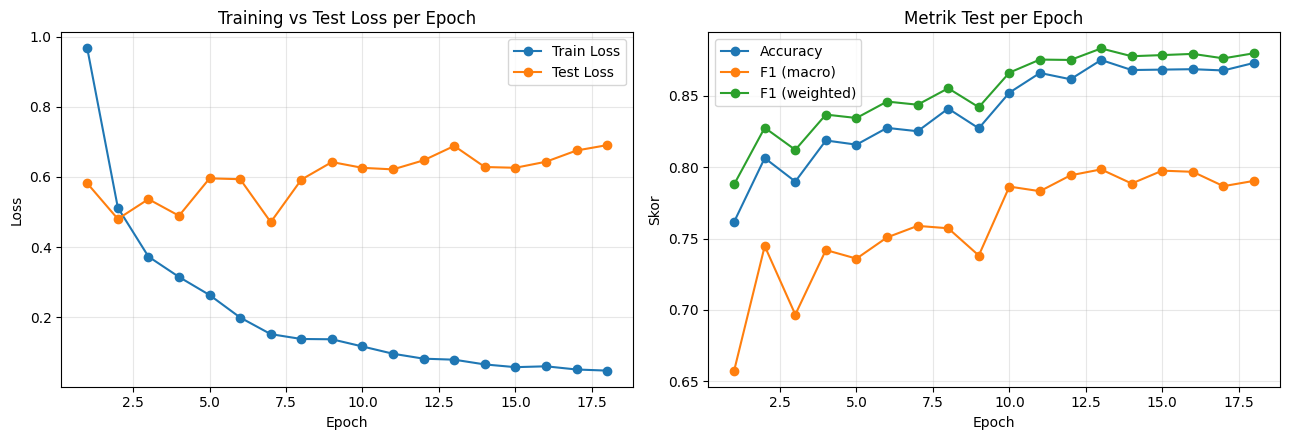

In [31]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["test_loss"], marker="o", label="Test Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Test Loss per Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["test_accuracy"], marker="o", label="Accuracy")
axes[1].plot(epochs_range, history["test_f1_macro"], marker="o", label="F1 (macro)")
axes[1].plot(epochs_range, history["test_f1_weighted"], marker="o", label="F1 (weighted)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Skor")
axes[1].set_title("Metrik Test per Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 20. Evaluasi Akhir Menggunakan Model Terbaik (`best.pth`)

In [32]:
best_checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
print(f"Memuat model terbaik dari epoch {best_checkpoint['epoch']} (macro F1 test={best_checkpoint['test_f1_macro']:.4f})")

final_metrics = evaluate(model, test_loader, criterion, DEVICE)

print("\n=== METRIK EVALUASI AKHIR (level segmen) ===")
print(f"Accuracy           : {final_metrics['accuracy']:.4f}")
print(f"Precision (macro)  : {final_metrics['precision_macro']:.4f}")
print(f"Recall (macro)     : {final_metrics['recall_macro']:.4f}")
print(f"F1-score (macro)   : {final_metrics['f1_macro']:.4f}")
print(f"Precision (weighted): {final_metrics['precision_weighted']:.4f}")
print(f"Recall (weighted)   : {final_metrics['recall_weighted']:.4f}")
print(f"F1-score (weighted) : {final_metrics['f1_weighted']:.4f}")

print("\nClassification report:")
print(classification_report(
    final_metrics["y_true"], final_metrics["y_pred"],
    labels=range(NUM_CLASSES), target_names=CLASS_NAMES, zero_division=0,
))


Memuat model terbaik dari epoch 13 (macro F1 test=0.7985)

=== METRIK EVALUASI AKHIR (level segmen) ===
Accuracy           : 0.8751
Precision (macro)  : 0.7901
Recall (macro)     : 0.8168
F1-score (macro)   : 0.7985
Precision (weighted): 0.8960
Recall (weighted)   : 0.8751
F1-score (weighted) : 0.8832

Classification report:
              precision    recall  f1-score   support

          AP       0.81      0.68      0.74        87
    Artifact       1.00      1.00      1.00        32
      Benign       0.43      0.68      0.53       170
         CAD       0.89      0.91      0.90       205
          MR       0.94      0.91      0.93        93
          MS       1.00      1.00      1.00        40
         MVP       0.59      0.63      0.61       199
      Normal       0.97      0.92      0.94      2473
          PC       0.48      0.63      0.55       105

    accuracy                           0.88      3404
   macro avg       0.79      0.82      0.80      3404
weighted avg       0.90

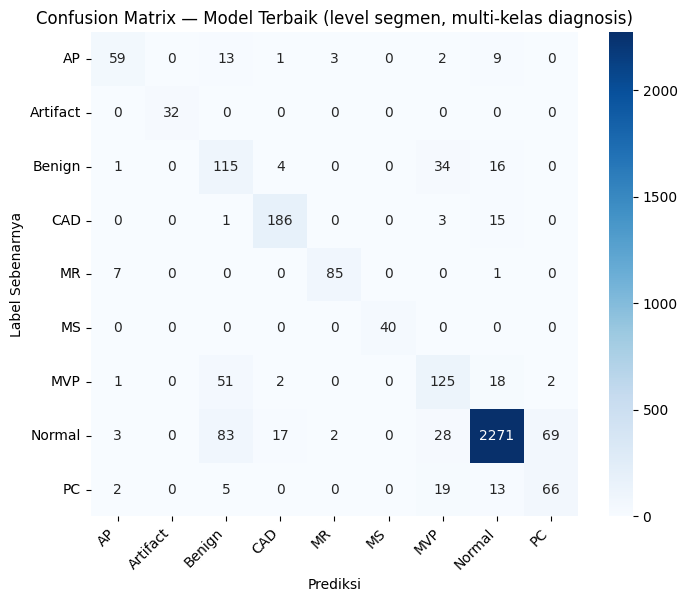

In [34]:
cm = confusion_matrix(final_metrics["y_true"], final_metrics["y_pred"], labels=range(NUM_CLASSES))

fig_size = max(6, NUM_CLASSES * 0.8)
plt.figure(figsize=(fig_size, fig_size * 0.85))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
)
plt.xlabel("Prediksi")
plt.ylabel("Label Sebenarnya")
plt.title("Confusion Matrix — Model Terbaik (level segmen, multi-kelas diagnosis)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 21. Evaluasi Level-Audio dengan Majority Voting

=== METRIK EVALUASI AKHIR (level audio / majority voting) ===
Jumlah audio test : 847
Accuracy          : 0.9209
Precision (macro) : 0.8431
Recall (macro)    : 0.8968
F1-score (macro)  : 0.8634


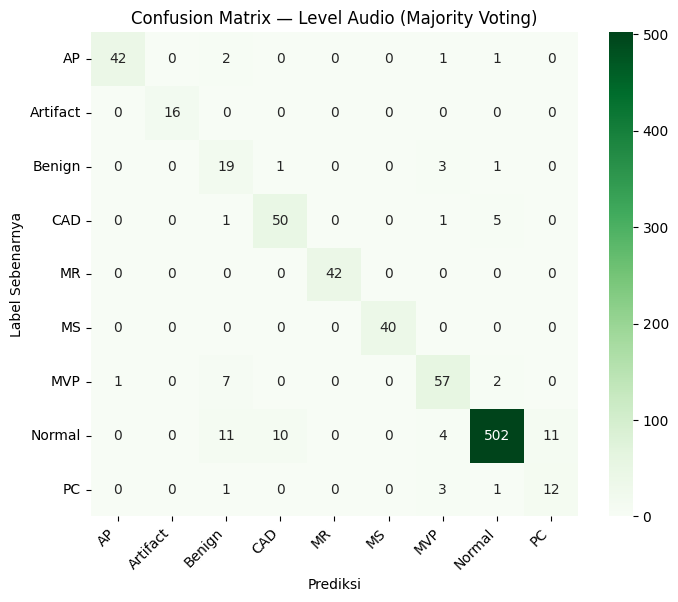

In [36]:
pred_df = test_segments_df.copy().reset_index(drop=True)
pred_df["y_true"] = final_metrics["y_true"]
pred_df["y_pred"] = final_metrics["y_pred"]

record_level = (
    pred_df.groupby("record_id")
    .agg(
        y_true=("y_true", "first"),
        y_pred_majority=("y_pred", lambda s: s.value_counts().idxmax()),
        n_segments=("y_pred", "count"),
    )
    .reset_index()
)

acc_r = accuracy_score(record_level["y_true"], record_level["y_pred_majority"])
prec_r, rec_r, f1_r, _ = precision_recall_fscore_support(
    record_level["y_true"], record_level["y_pred_majority"],
    average="macro", zero_division=0, labels=range(NUM_CLASSES),
)

print("=== METRIK EVALUASI AKHIR (level audio / majority voting) ===")
print(f"Jumlah audio test : {len(record_level)}")
print(f"Accuracy          : {acc_r:.4f}")
print(f"Precision (macro) : {prec_r:.4f}")
print(f"Recall (macro)    : {rec_r:.4f}")
print(f"F1-score (macro)  : {f1_r:.4f}")

cm_r = confusion_matrix(record_level["y_true"], record_level["y_pred_majority"], labels=range(NUM_CLASSES))
plt.figure(figsize=(fig_size, fig_size * 0.85))
sns.heatmap(
    cm_r, annot=True, fmt="d", cmap="Greens",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
)
plt.xlabel("Prediksi")
plt.ylabel("Label Sebenarnya")
plt.title("Confusion Matrix — Level Audio (Majority Voting)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
